# Day 4 · Hypothesis Testing
### *Is it a real effect — or just luck?*

Part of the **30 Days of Machine Learning** series · companion notebook to the LinkedIn carousel.

Every A/B test, every "did the new model beat the old one?" and every "is this drop real?" question comes down to the same logic: **compare what you saw against what luck alone would produce.** This notebook builds that intuition from scratch and then walks through the five tests that cover most day-to-day analytics work.

**What you'll do**

| # | Section | Key question |
|---|---------|--------------|
| 1 | Setup | Reproducible environment |
| 2 | The p-value from scratch | What does "p = 0.02" literally mean? |
| 3 | Test 1 — Welch t-test | Do two independent groups have different averages? |
| 4 | Test 2 — Paired t-test | Did the *same* units change before vs. after? |
| 5 | Test 3 — Two-proportion / chi-square | Did the conversion *rate* change? |
| 6 | Test 4 — Mann-Whitney U | What if the data is skewed? |
| 7 | Test 5 — One-way ANOVA + Tukey | Do 3+ groups differ? Which ones? |
| 8 | Two ways to be wrong (Type I / II, power) | How many users do I need? |
| 9 | Two traps | Multiple testing, and "significant" ≠ "important" |
| 10 | Cheat sheet + helper | Which test do I pick? |
| 11 | Save results | Numbers used in the carousel |

> **About the data.** All datasets are *simulated* with a fixed random seed so results are identical on every run. Every output below was produced by running the cells top-to-bottom.

---

## 1 · Setup

We only need the standard scientific-Python stack: **NumPy** (arrays and random numbers), **pandas** (tables), **SciPy** (`scipy.stats` holds every test we use) and **Matplotlib** (plots).

Three habits worth copying into your own work:

* **Fix the random seed** so anyone can reproduce your numbers.
* **Decide α (the significance level) *before* looking at results.** We use the conventional 5%.
* **Keep a `results` dictionary** so the numbers you quote in a report come straight from code, not from memory.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from IPython.display import display

print(f"numpy {np.__version__} | pandas {pd.__version__} | scipy {scipy.__version__} | matplotlib {matplotlib.__version__}")

# ---- Reproducibility & global settings ----------------------------------
SEED = 42
rng = np.random.default_rng(SEED)   # one generator reused everywhere
ALPHA = 0.05                        # significance level, chosen BEFORE looking at data

# ---- Folders for everything this notebook produces -----------------------
for folder in ("images", "data", "results"):
    Path(folder).mkdir(exist_ok=True)

# ---- Palette shared with the carousel ------------------------------------
NAVY, ORANGE, GREEN, CORAL, INK, MUTED = "#2E3A7F", "#F5A400", "#20A070", "#FF5F63", "#1B2150", "#5B6280"

plt.rcParams.update({
    "figure.figsize": (9, 4.8), "figure.dpi": 100, "font.size": 13,
    "axes.titlesize": 15, "axes.titleweight": "bold", "axes.labelsize": 13,
    "axes.spines.top": False, "axes.spines.right": False,
    "savefig.facecolor": "white",
})

# ---- Small helpers --------------------------------------------------------
def verdict(p, alpha=ALPHA):
    """Turn a p-value into the plain-English decision."""
    if p < alpha:
        return f"p = {p:.4g} < alpha = {alpha}  ->  REJECT H0 (statistically significant)"
    return f"p = {p:.4g} >= alpha = {alpha}  ->  FAIL TO REJECT H0 (not significant)"

def save_fig(fig, name):
    """Save a high-resolution copy into images/ (used by the carousel)."""
    fig.savefig(f"images/{name}.png", dpi=200, bbox_inches="tight", facecolor="white")

results = {}   # every headline number is stored here and exported at the end
print("\nSetup complete. alpha =", ALPHA, "| seed =", SEED)

numpy 2.4.4 | pandas 3.0.2 | scipy 1.17.1 | matplotlib 3.10.8

Setup complete. alpha = 0.05 | seed = 42


## 2 · The p-value from scratch

**The hypotheses**

* **H₀ (null hypothesis):** nothing is going on — any difference is random noise.
* **H₁ (alternative hypothesis):** there is a real effect.

**The p-value** answers one very specific question:

> *If H₀ were true, how often would I see a result at least this extreme just by chance?*

A small p-value means "this would be very surprising in a world where nothing is happening", so we doubt H₀. It does **not** tell you the probability that H₀ is true, and it does **not** tell you how big or important the effect is.

**A worked example.** A coin lands heads **62 times in 100 flips**. Is it biased?

1. Assume H₀: the coin is fair (P(heads) = 0.5).
2. Simulate 200,000 experiments of 100 fair flips each. That gives us the *null distribution* — what luck alone produces.
3. Count how often luck produces a result **as far from 50 as ours is (12 heads away, in either direction)**. That fraction *is* the p-value.
4. Cross-check against the exact binomial test.

In [2]:
n_flips, observed_heads = 100, 62
gap = abs(observed_heads - n_flips * 0.5)          # how far from 'perfectly fair' we landed

# --- 1) Simulation: 200,000 experiments in a world where H0 is true --------
null_heads = rng.binomial(n=n_flips, p=0.5, size=200_000)
p_simulated = np.mean(np.abs(null_heads - n_flips * 0.5) >= gap)   # two-sided

# --- 2) Exact answer from the binomial distribution ------------------------
p_exact = stats.binomtest(observed_heads, n_flips, p=0.5, alternative="two-sided").pvalue

print(f"Observed heads          : {observed_heads} / {n_flips}")
print(f"Simulated p-value       : {p_simulated:.4f}   (share of fair-coin experiments at least this extreme)")
print(f"Exact binomial p-value  : {p_exact:.4f}")
print(verdict(p_exact))

results["pvalue_demo"] = {"heads": observed_heads, "flips": n_flips,
                          "p_exact": float(p_exact), "p_simulated": float(p_simulated)}

Observed heads          : 62 / 100
Simulated p-value       : 0.0210   (share of fair-coin experiments at least this extreme)
Exact binomial p-value  : 0.0210
p = 0.02098 < alpha = 0.05  ->  REJECT H0 (statistically significant)


The simulation and the exact test agree, which is the whole point: **a p-value is just a tail area of the null distribution.** Let's look at it. The coral bars are the "as extreme or more" outcomes — their combined share of all simulations is the p-value.

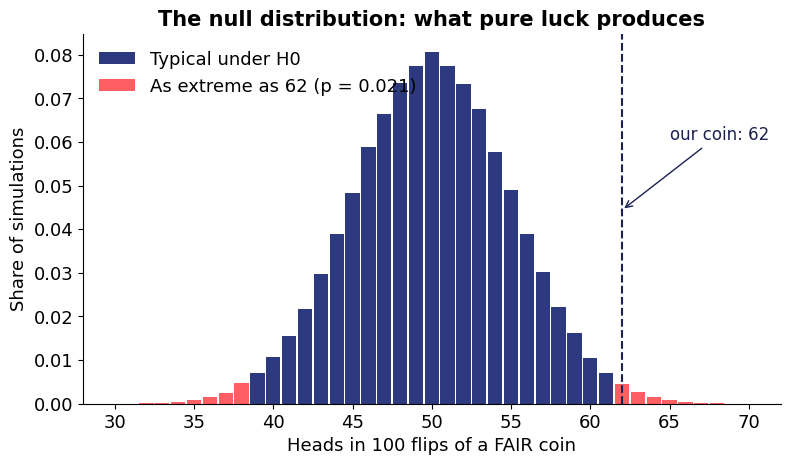

In [3]:
fig, ax = plt.subplots()
values, counts = np.unique(null_heads, return_counts=True)
share = counts / counts.sum()
extreme = np.abs(values - n_flips * 0.5) >= gap

ax.bar(values[~extreme], share[~extreme], color=NAVY, width=0.9, label="Typical under H0")
ax.bar(values[extreme],  share[extreme],  color=CORAL, width=0.9, label=f"As extreme as {observed_heads} (p = {p_exact:.3f})")
ax.axvline(observed_heads, color=INK, ls="--", lw=1.5)
ax.annotate("our coin: 62", xy=(observed_heads, share.max() * 0.55), xytext=(observed_heads + 3, share.max() * 0.75),
            arrowprops=dict(arrowstyle="->", color=INK), color=INK, fontsize=12)
ax.set_xlim(28, 72)
ax.set_xlabel("Heads in 100 flips of a FAIR coin")
ax.set_ylabel("Share of simulations")
ax.set_title("The null distribution: what pure luck produces")
ax.legend(frameon=False, loc="upper left")
save_fig(fig, "pvalue_null_distribution")
plt.show()

### Three things a p-value is *not*

| Common belief | Reality |
|---|---|
| "p = 0.03 means a 3% chance H₀ is true." | It is the chance of data this extreme **if** H₀ is true. It says nothing directly about the probability of H₀. |
| "p < 0.05 means the effect is big." | p mixes effect size **and** sample size. A tiny effect can be "significant" with enough data (see Section 9). |
| "p > 0.05 proves there is no effect." | It only means we lack evidence. Maybe the test was under-powered (see Section 8). |

---

## 3 · Test 1 — Welch t-test: two independent averages

**Question:** *Does the new onboarding flow increase weekly engagement compared with the old one?*

**Use it when:** you compare the **means of two independent groups** and the outcome is numeric (minutes, revenue, latency…).

**Why Welch and not the classic Student t-test?** Welch's version does **not** assume both groups have the same variance, and it costs almost nothing when they do. It is the safer default — `equal_var=False` in SciPy.

**Assumptions:** observations are independent; each group is roughly normal *or* the samples are reasonably large (central limit theorem).

We simulate 200 users per group. The new flow has a slightly higher mean *and* a slightly larger spread.

In [4]:
n = 200
control   = rng.normal(loc=52.0, scale=12.0, size=n)   # old onboarding: weekly minutes
treatment = rng.normal(loc=55.5, scale=14.0, size=n)   # new onboarding

engagement = pd.DataFrame({
    "group":   ["control"] * n + ["new_flow"] * n,
    "minutes": np.concatenate([control, treatment]),
})
engagement.to_csv("data/onboarding_engagement.csv", index=False)

summary = engagement.groupby("group")["minutes"].agg(["count", "mean", "median", "std"]).round(2)
display(summary)

,count,mean,median,std
group,,,,
control,200,50.95,49.70,11.94
new_flow,200,55.19,54.71,14.11


**Check the assumptions before you trust the test.**

* **Shapiro-Wilk** tests normality (H₀: the data is normal). With large samples it flags even harmless deviations, so treat it as a hint and look at a histogram too.
* **Levene** tests equal variances (H₀: variances are equal). If it rejects, that is exactly why we use Welch.

In [5]:
for name, sample in [("control", control), ("new_flow", treatment)]:
    w, p = stats.shapiro(sample)
    print(f"Shapiro-Wilk  {name:<9}: W = {w:.4f}, p = {p:.3f}  ->  {'looks normal' if p >= ALPHA else 'non-normal'}")

lev_stat, lev_p = stats.levene(control, treatment)
print(f"Levene (equal variances): stat = {lev_stat:.3f}, p = {lev_p:.3f}  ->  "
      f"{'variances similar' if lev_p >= ALPHA else 'variances differ - Welch is the right call'}")

Shapiro-Wilk  control  : W = 0.9906, p = 0.216  ->  looks normal
Shapiro-Wilk  new_flow : W = 0.9954, p = 0.807  ->  looks normal
Levene (equal variances): stat = 3.511, p = 0.062  ->  variances similar


**Run the test.** Besides the p-value, always report:

* the **difference in means** with a **95% confidence interval** (how large, and how precisely we know it);
* an **effect size** — *Cohen's d* = difference ÷ pooled standard deviation. Rough guide: 0.2 small, 0.5 medium, 0.8 large.

We also compute the confidence interval by hand to show there is no magic inside `scipy`.

In [6]:
res = stats.ttest_ind(treatment, control, equal_var=False)     # Welch t-test

diff = treatment.mean() - control.mean()
v_t, v_c = treatment.var(ddof=1) / n, control.var(ddof=1) / n
se = np.sqrt(v_t + v_c)
df_welch = (v_t + v_c) ** 2 / (v_t ** 2 / (n - 1) + v_c ** 2 / (n - 1))    # Welch-Satterthwaite d.o.f.
t_crit = stats.t.ppf(1 - ALPHA / 2, df_welch)
ci_low, ci_high = diff - t_crit * se, diff + t_crit * se

pooled_sd = np.sqrt((treatment.var(ddof=1) + control.var(ddof=1)) / 2)
cohens_d = diff / pooled_sd

# sanity check: our manual CI must match SciPy's own
ci_scipy = res.confidence_interval(0.95)
assert np.isclose(ci_low, ci_scipy.low) and np.isclose(ci_high, ci_scipy.high)

print(f"Mean difference (new - old): {diff:.2f} minutes   95% CI [{ci_low:.2f}, {ci_high:.2f}]")
print(f"t = {res.statistic:.3f}, degrees of freedom = {df_welch:.1f}")
print(f"Cohen's d = {cohens_d:.2f}")
print(verdict(res.pvalue))

results["welch"] = {"mean_control": float(control.mean()), "mean_treatment": float(treatment.mean()),
                    "diff": float(diff), "ci_low": float(ci_low), "ci_high": float(ci_high),
                    "t": float(res.statistic), "df": float(df_welch),
                    "p": float(res.pvalue), "cohens_d": float(cohens_d), "n_per_group": n}

Mean difference (new - old): 4.25 minutes   95% CI [1.68, 6.82]
t = 3.249, degrees of freedom = 387.4
Cohen's d = 0.32
p = 0.001258 < alpha = 0.05  ->  REJECT H0 (statistically significant)


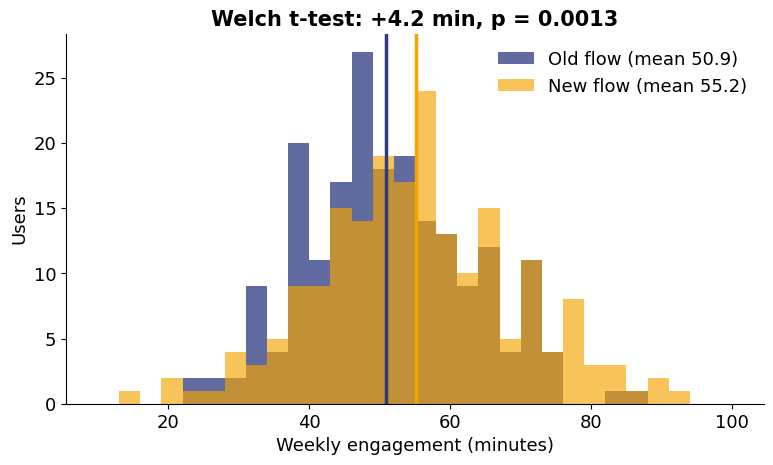

In [7]:
fig, ax = plt.subplots()
bins = np.linspace(10, 100, 31)
ax.hist(control,   bins=bins, alpha=0.75, color=NAVY,   label=f"Old flow (mean {control.mean():.1f})")
ax.hist(treatment, bins=bins, alpha=0.65, color=ORANGE, label=f"New flow (mean {treatment.mean():.1f})")
ax.axvline(control.mean(),   color=NAVY,   lw=2.5)
ax.axvline(treatment.mean(), color=ORANGE, lw=2.5)
ax.set_xlabel("Weekly engagement (minutes)")
ax.set_ylabel("Users")
ax.set_title(f"Welch t-test: +{diff:.1f} min, p = {res.pvalue:.4f}")
ax.legend(frameon=False)
save_fig(fig, "welch_ttest")
plt.show()

**Reading it:** the two histograms overlap heavily — that is normal. The test does not ask whether every user in one group beats every user in the other; it asks whether the **difference between the group averages** is larger than sampling noise would explain. The confidence interval tells you the plausible range of the true lift.

---

## 4 · Test 2 — Paired t-test: same units, before vs. after

**Question:** *Did a query optimisation reduce latency on the same 40 services?*

**Use it when:** every observation in group A has a natural partner in group B — the **same** users, servers or patients measured twice.

**Why pairing matters:** services differ hugely from each other (some are always slow). Pairing subtracts each service's own baseline, so that large between-service variation stops drowning out the improvement. The paired test is just a **one-sample t-test on the differences**.

In [8]:
n_services = 40
before = rng.normal(loc=480, scale=60, size=n_services)            # latency in ms
after  = before + rng.normal(loc=-25, scale=20, size=n_services)   # same services, ~25 ms faster on average

latency = pd.DataFrame({"service": np.arange(1, n_services + 1), "before_ms": before, "after_ms": after})
latency.to_csv("data/latency_before_after.csv", index=False)

change = after - before
paired = stats.ttest_rel(after, before)

# Proof that "paired t-test" == "one-sample t-test on the differences"
one_sample = stats.ttest_1samp(change, popmean=0)
assert np.isclose(paired.pvalue, one_sample.pvalue)

# What happens if we (wrongly) ignore the pairing?
wrong = stats.ttest_ind(after, before, equal_var=False)

d_z = change.mean() / change.std(ddof=1)          # effect size for paired data
ci = paired.confidence_interval(0.95)

print(f"Mean change: {change.mean():.1f} ms   95% CI [{ci.low:.1f}, {ci.high:.1f}]")
print(f"Paired t-test  : t = {paired.statistic:.3f}, {verdict(paired.pvalue)}")
print(f"Effect size d_z: {d_z:.2f}")
print(f"\nIgnoring the pairing (unpaired Welch) would give p = {wrong.pvalue:.3f}  "
      f"-> {'we would MISS a real improvement' if wrong.pvalue >= ALPHA else 'still significant, but far weaker evidence'}")

results["paired"] = {"n": n_services, "mean_before": float(before.mean()), "mean_after": float(after.mean()),
                     "mean_change": float(change.mean()), "ci_low": float(ci.low), "ci_high": float(ci.high),
                     "t": float(paired.statistic), "p": float(paired.pvalue), "dz": float(d_z),
                     "p_if_unpaired": float(wrong.pvalue)}

Mean change: -22.7 ms   95% CI [-28.8, -16.7]
Paired t-test  : t = -7.572, p = 3.555e-09 < alpha = 0.05  ->  REJECT H0 (statistically significant)
Effect size d_z: -1.20

Ignoring the pairing (unpaired Welch) would give p = 0.096  -> we would MISS a real improvement


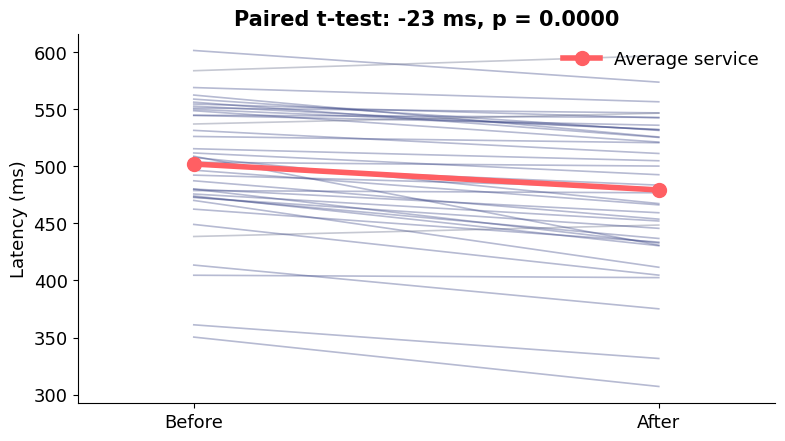

In [9]:
fig, ax = plt.subplots()
for b, a in zip(before, after):
    ax.plot([0, 1], [b, a], color=(MUTED if a >= b else NAVY), alpha=0.35, lw=1.2)
ax.plot([0, 1], [before.mean(), after.mean()], color=CORAL, lw=4, marker="o", ms=10, label="Average service")
ax.set_xticks([0, 1], ["Before", "After"])
ax.set_xlim(-0.25, 1.25)
ax.set_ylabel("Latency (ms)")
ax.set_title(f"Paired t-test: {change.mean():.0f} ms, p = {paired.pvalue:.4f}")
ax.legend(frameon=False, loc="upper right")
save_fig(fig, "paired_ttest")
plt.show()

**Reading it:** each thin line is one service. Most slope downward, and the test asks whether the *average slope* is credibly different from zero. Notice how much weaker the evidence looks if you (incorrectly) treat the two columns as independent groups — the message above shows the difference. **Choose the test that matches how the data was collected.**

---

## 5 · Test 3 — Two-proportion z-test (and chi-square)

**Question:** *Did the redesigned checkout page change the conversion rate?*

**Use it when:** the outcome is **binary** (converted / didn't, clicked / didn't, churned / stayed) and you compare two groups.

For a 2×2 table, the **two-proportion z-test** and the **chi-square test of independence** are the *same test* — χ² = z². We compute both and prove it.

**Assumption:** enough observations in every cell (a common rule: expected counts ≥ 5). For tiny samples use Fisher's exact test (`stats.fisher_exact`).

In [10]:
n_a = n_b = 5_000
conv_a = int(rng.binomial(n_a, 0.100))     # old page: true rate 10.0%
conv_b = int(rng.binomial(n_b, 0.115))     # new page: true rate 11.5%

rate_a, rate_b = conv_a / n_a, conv_b / n_b
table = pd.DataFrame({"visitors": [n_a, n_b], "conversions": [conv_a, conv_b],
                      "rate": [rate_a, rate_b]}, index=["A (old)", "B (new)"])
table.to_csv("data/ab_conversions.csv")
display(table.round(4))

# --- Two-proportion z-test, computed by hand --------------------------------
p_pool = (conv_a + conv_b) / (n_a + n_b)                       # pooled rate under H0
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1 / n_a + 1 / n_b))
z = (rate_b - rate_a) / se_pool
p_z = 2 * stats.norm.sf(abs(z))                                # two-sided

# --- Chi-square test of independence on the 2x2 table -----------------------
contingency = np.array([[conv_a, n_a - conv_a],
                        [conv_b, n_b - conv_b]])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency, correction=False)

# --- 95% confidence interval for the difference in rates ---------------------
se_diff = np.sqrt(rate_a * (1 - rate_a) / n_a + rate_b * (1 - rate_b) / n_b)
diff_rate = rate_b - rate_a
ci_low, ci_high = diff_rate - 1.96 * se_diff, diff_rate + 1.96 * se_diff

print(f"\nDifference in conversion: {diff_rate * 100:+.2f} percentage points   "
      f"95% CI [{ci_low * 100:.2f}, {ci_high * 100:.2f}] pp")
print(f"Relative lift           : {diff_rate / rate_a * 100:+.1f}%")
print(f"z-test    : z = {z:.3f},  p = {p_z:.5f}")
print(f"chi-square: chi2 = {chi2:.3f}, p = {p_chi:.5f}   (z squared = {z ** 2:.3f})")
assert np.isclose(z ** 2, chi2) and np.isclose(p_z, p_chi)
print(verdict(p_z))

results["proportions"] = {"n_a": n_a, "n_b": n_b, "conv_a": conv_a, "conv_b": conv_b,
                          "rate_a": float(rate_a), "rate_b": float(rate_b),
                          "diff_pp": float(diff_rate * 100), "ci_low_pp": float(ci_low * 100),
                          "ci_high_pp": float(ci_high * 100), "rel_lift_pct": float(diff_rate / rate_a * 100),
                          "z": float(z), "chi2": float(chi2), "p": float(p_z)}

,visitors,conversions,rate
A (old),5000,496,0.0992
B (new),5000,579,0.1158



Difference in conversion: +1.66 percentage points   95% CI [0.45, 2.87] pp
Relative lift           : +16.7%
z-test    : z = 2.680,  p = 0.00737
chi-square: chi2 = 7.180, p = 0.00737   (z squared = 7.180)
p = 0.007371 < alpha = 0.05  ->  REJECT H0 (statistically significant)


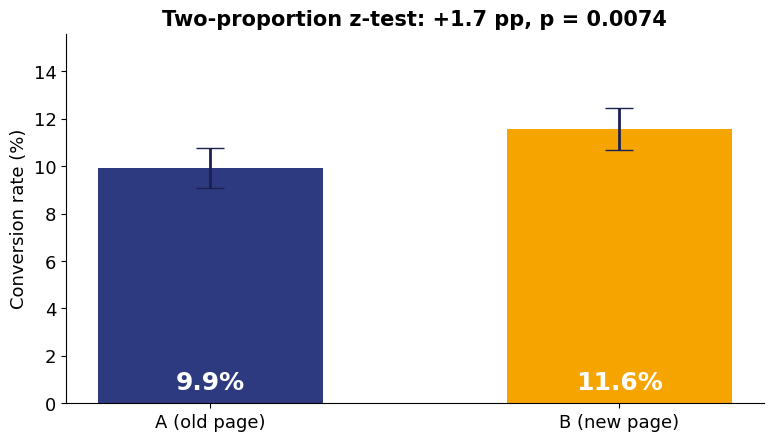

In [11]:
fig, ax = plt.subplots()
rates = np.array([rate_a, rate_b]) * 100
errs = 1.96 * np.sqrt(np.array([rate_a * (1 - rate_a) / n_a, rate_b * (1 - rate_b) / n_b])) * 100
bars = ax.bar(["A (old page)", "B (new page)"], rates, yerr=errs, capsize=10,
              color=[NAVY, ORANGE], width=0.55, error_kw=dict(lw=2, ecolor=INK))
for bar, r in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, 0.6, f"{r:.1f}%", ha="center", color="white", fontsize=18, fontweight="bold")
ax.set_ylabel("Conversion rate (%)")
ax.set_ylim(0, max(rates + errs) * 1.25)
ax.set_title(f"Two-proportion z-test: {diff_rate * 100:+.1f} pp, p = {p_z:.4f}")
save_fig(fig, "proportion_test")
plt.show()

**Reading it:** the whiskers are 95% confidence intervals for each rate. Even when the two intervals just touch, the *difference* can still be significant — the test compares the difference directly, not whether the individual intervals overlap. Do not use "the error bars overlap" as a significance test.

---

## 6 · Test 4 — Mann-Whitney U: when the data is skewed

**Question:** *Do users spend longer on the new page design?* Session duration is the textbook **right-skewed** metric (Day 3!): most sessions are short and a few are very long.

**Use it when:** you compare two independent groups but the data is clearly skewed, has outliers, or is ordinal (ratings 1–5), and the sample is small enough that you don't trust the t-test.

**How it works:** it ranks *all* observations together and asks whether one group's ranks are systematically higher. Long outliers can no longer dominate, because a huge value is just "the highest rank".

**Careful wording:** Mann-Whitney tests whether values in one group *tend to be larger* — the probability of superiority — which usually, but not always, lines up with a difference in medians.

In [12]:
n = 200
old_design = rng.lognormal(mean=np.log(4.0), sigma=0.8, size=n)   # median 4.0 min, long right tail
new_design = rng.lognormal(mean=np.log(4.9), sigma=0.8, size=n)   # median 4.9 min

sessions = pd.DataFrame({"design": ["old"] * n + ["new"] * n,
                         "minutes": np.concatenate([old_design, new_design])})
sessions.to_csv("data/session_duration.csv", index=False)
display(sessions.groupby("design")["minutes"].agg(["count", "mean", "median", "std", "skew"]).round(2))

# Are the data normal? Compare raw vs log-transformed
print(f"\nShapiro p (raw minutes, old design): {stats.shapiro(old_design).pvalue:.2e}  -> clearly NOT normal")
print(f"Shapiro p (log minutes, old design): {stats.shapiro(np.log(old_design)).pvalue:.3f}  -> normal after log transform")

,count,mean,median,std,skew
design,,,,,
new,200,6.52,4.76,5.95,2.58
old,200,5.51,4.08,4.64,2.13



Shapiro p (raw minutes, old design): 1.46e-15  -> clearly NOT normal
Shapiro p (log minutes, old design): 0.733  -> normal after log transform


In [13]:
mw = stats.mannwhitneyu(new_design, old_design, alternative="two-sided")
tt = stats.ttest_ind(new_design, old_design, equal_var=False)

prob_superiority = mw.statistic / (n * n)     # P(random new-design session > random old-design session)

print(f"Mann-Whitney U : U = {mw.statistic:.0f}, {verdict(mw.pvalue)}")
print(f"Welch t-test   : t = {tt.statistic:.3f}, p = {tt.pvalue:.4f}   (for comparison - it compares MEANS, which the tail distorts)")
print(f"Probability of superiority: {prob_superiority:.3f}  "
      f"(a random new-design session is longer than a random old-design one {prob_superiority * 100:.0f}% of the time; 50% = no difference)")
print(f"Medians: old = {np.median(old_design):.2f} min, new = {np.median(new_design):.2f} min")

results["mannwhitney"] = {"n_per_group": n, "median_old": float(np.median(old_design)), "median_new": float(np.median(new_design)),
                          "mean_old": float(old_design.mean()), "mean_new": float(new_design.mean()),
                          "U": float(mw.statistic), "p": float(mw.pvalue), "p_welch": float(tt.pvalue),
                          "prob_superiority": float(prob_superiority), "skew_old": float(stats.skew(old_design))}

Mann-Whitney U : U = 21777, p = 0.1244 >= alpha = 0.05  ->  FAIL TO REJECT H0 (not significant)
Welch t-test   : t = 1.910, p = 0.0569   (for comparison - it compares MEANS, which the tail distorts)
Probability of superiority: 0.544  (a random new-design session is longer than a random old-design one 54% of the time; 50% = no difference)
Medians: old = 4.08 min, new = 4.76 min


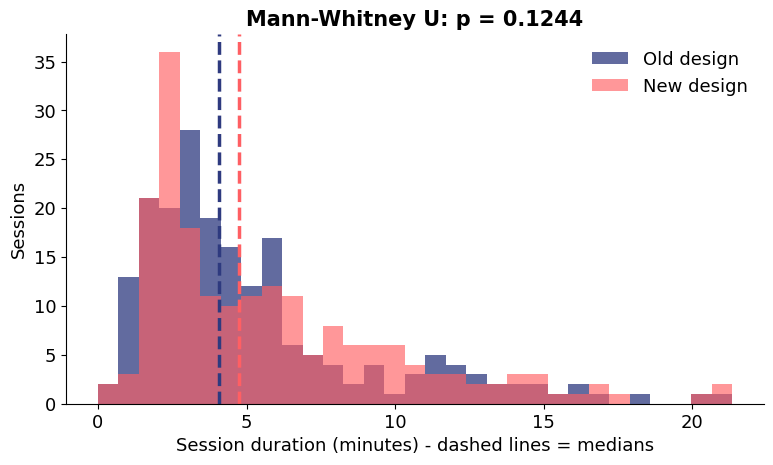

In [14]:
fig, ax = plt.subplots()
cap = np.percentile(np.concatenate([old_design, new_design]), 98)     # trim the extreme tail for readability
bins = np.linspace(0, cap, 32)
ax.hist(old_design, bins=bins, alpha=0.75, color=NAVY,  label="Old design")
ax.hist(new_design, bins=bins, alpha=0.65, color=CORAL, label="New design")
ax.axvline(np.median(old_design), color=NAVY,  lw=2.5, ls="--")
ax.axvline(np.median(new_design), color=CORAL, lw=2.5, ls="--")
ax.set_xlabel("Session duration (minutes) - dashed lines = medians")
ax.set_ylabel("Sessions")
ax.set_title(f"Mann-Whitney U: p = {mw.pvalue:.4f}")
ax.legend(frameon=False)
save_fig(fig, "mannwhitney")
plt.show()

**Reading it:** both histograms have the long right tail from Day 3. The dashed medians sit clearly apart and the rank-based test picks that up without being pulled around by a few marathon sessions. When the data is this skewed, report **medians** (and the probability of superiority) rather than means.

---

## 7 · Test 5 — One-way ANOVA (+ Tukey HSD): three or more groups

**Question:** *Do three marketing channels produce different revenue per user?*

**Use it when:** you compare the means of **3+ independent groups**.

**Why not run three t-tests?** Every extra test is another chance for a false alarm (Section 9 quantifies it). ANOVA asks **one** omnibus question first — *"is at least one group different?"* — and only then do we look at pairs, using **Tukey's HSD**, which controls the error rate across all pairwise comparisons.

**Assumptions:** independent observations, roughly normal groups, similar variances. If those fail, use **Kruskal-Wallis** (`stats.kruskal`), the rank-based cousin of ANOVA.

In [15]:
n = 80
groups = {
    "Email":  rng.normal(50.0, 8.0, n),
    "Social": rng.normal(54.0, 8.0, n),
    "Search": rng.normal(55.5, 8.0, n),
}
channel = pd.DataFrame([(k, v) for k, arr in groups.items() for v in arr], columns=["channel", "revenue"])
channel.to_csv("data/channel_revenue.csv", index=False)
display(channel.groupby("channel")["revenue"].agg(["count", "mean", "std"]).round(2))

lev_stat, lev_p = stats.levene(*groups.values())
print(f"\nLevene (equal variances): p = {lev_p:.3f}  ->  {'assumption OK' if lev_p >= ALPHA else 'variances differ'}")

# --- Omnibus test -----------------------------------------------------------
anova = stats.f_oneway(*groups.values())

# --- Effect size: eta squared = between-group variation / total variation ---
grand_mean = channel["revenue"].mean()
ss_between = sum(len(v) * (v.mean() - grand_mean) ** 2 for v in groups.values())
ss_total = ((channel["revenue"] - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total

print(f"ANOVA: F = {anova.statistic:.3f}, {verdict(anova.pvalue)}")
print(f"Effect size eta^2 = {eta_sq:.3f}  ({eta_sq * 100:.1f}% of revenue variation is explained by channel)")

,count,mean,std
channel,,,
Email,80,50.06,8.44
Search,80,55.92,7.96
Social,80,53.64,7.89



Levene (equal variances): p = 0.731  ->  assumption OK
ANOVA: F = 10.609, p = 3.867e-05 < alpha = 0.05  ->  REJECT H0 (statistically significant)
Effect size eta^2 = 0.082  (8.2% of revenue variation is explained by channel)


A significant ANOVA only says *"somewhere there is a difference"*. **Tukey's HSD** now tells us *which* pairs differ, while keeping the overall false-alarm rate at 5%.

In [16]:
names = list(groups)
tukey = stats.tukey_hsd(*groups.values())
ci = tukey.confidence_interval(confidence_level=0.95)

rows = []
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        rows.append({"comparison": f"{names[j]} - {names[i]}",
                     "mean_diff": tukey.statistic[j, i],
                     "ci_low": ci.low[j, i], "ci_high": ci.high[j, i],
                     "p_adj": tukey.pvalue[j, i],
                     "significant": tukey.pvalue[j, i] < ALPHA})
tukey_table = pd.DataFrame(rows).round(3)
display(tukey_table)

results["anova"] = {"n_per_group": n, "means": {k: float(v.mean()) for k, v in groups.items()},
                    "F": float(anova.statistic), "p": float(anova.pvalue), "eta_sq": float(eta_sq),
                    "tukey": {r["comparison"]: {"diff": float(r["mean_diff"]), "p_adj": float(r["p_adj"])} for r in rows}}

,comparison,mean_diff,ci_low,ci_high,p_adj,significant
0,Social - Email,3.574,0.554,6.595,0.016,True
1,Search - Email,5.852,2.831,8.873,0.000,True
2,Search - Social,2.278,-0.743,5.299,0.179,False


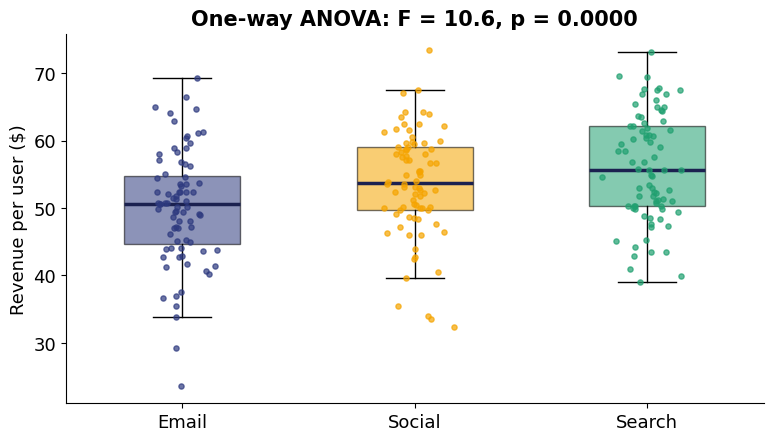

In [17]:
fig, ax = plt.subplots()
colors = [NAVY, ORANGE, GREEN]
bp = ax.boxplot(list(groups.values()), tick_labels=names, patch_artist=True, widths=0.5, showfliers=False,
                medianprops=dict(color=INK, lw=2.5))
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c); patch.set_alpha(0.55)
for k, (arr, c) in enumerate(zip(groups.values(), colors), start=1):
    ax.scatter(rng.normal(k, 0.06, len(arr)), arr, s=14, color=c, alpha=0.7, zorder=3)
ax.set_ylabel("Revenue per user ($)")
ax.set_title(f"One-way ANOVA: F = {anova.statistic:.1f}, p = {anova.pvalue:.4f}")
save_fig(fig, "anova")
plt.show()

**Reading it:** the boxes show medians and quartiles, the dots are individual users. ANOVA compares how far apart the group centres are relative to the spread *within* each group. The Tukey table above tells you which specific channels are separated — and, just as important, which are **not** (a non-significant pair is "no evidence of a difference", not "proven equal").

---

## 8 · Two ways to be wrong: Type I, Type II and power

|  | **H₀ is actually true** (no effect) | **H₀ is actually false** (real effect) |
|---|---|---|
| **We reject H₀** | ❌ **Type I error** (false positive) — probability = **α** | ✅ Correct — probability = **power** (1 − β) |
| **We keep H₀** | ✅ Correct | ❌ **Type II error** (false negative) — probability = **β** |

* **α** is the false-alarm rate you *choose* (5%).
* **Power** is the chance of detecting a real effect of a given size. The usual target is **80%**.
* Power depends on: effect size, sample size, variability and α.

### 8a · Prove that α really is the false-positive rate (an "A/A test")
If both groups come from the **same** distribution, H₀ is true by construction. Run 10,000 such tests: about 5% should come out "significant" by pure luck — and the p-values should be spread **uniformly** between 0 and 1.

A/A tests run            : 10,000
'Significant' at 5%      : 476  ->  false positive rate = 0.048


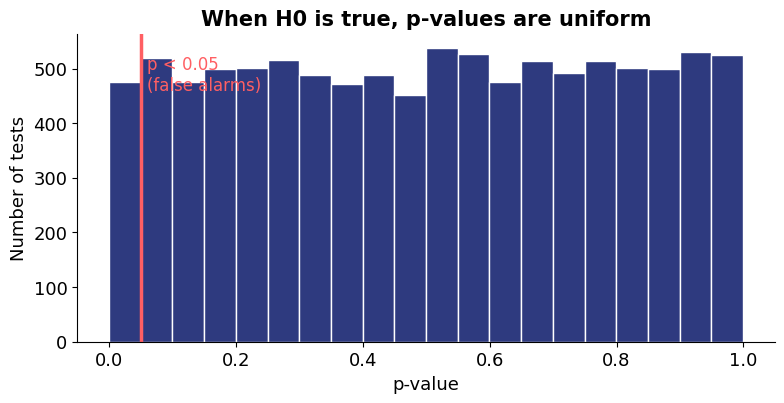

In [18]:
sims, n = 10_000, 50
a = rng.normal(0, 1, size=(sims, n))
b = rng.normal(0, 1, size=(sims, n))                     # same distribution: H0 is TRUE
p_aa = stats.ttest_ind(a, b, axis=1).pvalue              # 10,000 t-tests in one vectorised call

false_positive_rate = np.mean(p_aa < ALPHA)
print(f"A/A tests run            : {sims:,}")
print(f"'Significant' at 5%      : {(p_aa < ALPHA).sum():,}  ->  false positive rate = {false_positive_rate:.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(p_aa, bins=20, color=NAVY, edgecolor="white")
ax.axvline(ALPHA, color=CORAL, lw=2.5)
ax.text(ALPHA + 0.01, ax.get_ylim()[1] * 0.93, "p < 0.05\n(false alarms)", color=CORAL, fontsize=12, va="top")
ax.set_xlabel("p-value")
ax.set_ylabel("Number of tests")
ax.set_title("When H0 is true, p-values are uniform")
plt.show()

results["type1"] = {"sims": sims, "false_positive_rate": float(false_positive_rate)}

### 8b · Power and sample size
How many users per group do you need to detect a given effect? We compute power two ways and check they agree:

1. **Analytically**, using the non-central t distribution.
2. **By simulation** — generate many fake experiments with a *true* effect and count how often the test catches it.

Effect sizes are Cohen's d: **0.2 small · 0.3 modest · 0.5 medium**.

In [19]:
def power_analytic(d, n, alpha=ALPHA):
    """Power of a two-sided, two-sample t-test with n users per group and true effect size d."""
    df = 2 * n - 2
    nc = d * np.sqrt(n / 2)                       # non-centrality parameter
    t_crit = stats.t.ppf(1 - alpha / 2, df)
    return stats.nct.sf(t_crit, df, nc) + stats.nct.cdf(-t_crit, df, nc)

def power_sim(d, n, sims=2_000, alpha=ALPHA):
    """Same quantity, estimated by brute-force simulation."""
    a = rng.normal(0, 1, size=(sims, n))
    b = rng.normal(d, 1, size=(sims, n))
    return np.mean(stats.ttest_ind(b, a, axis=1).pvalue < alpha)

def n_for_power(d, target=0.80):
    """Smallest n per group that reaches the target power."""
    n = 2
    while power_analytic(d, n) < target:
        n += 1
    return n

effect_sizes = {0.2: CORAL, 0.3: ORANGE, 0.5: NAVY}
needed = {d: n_for_power(d) for d in effect_sizes}
print("Users needed PER GROUP for 80% power (alpha = 0.05):")
for d, n_req in needed.items():
    print(f"   effect size d = {d}: {n_req:>4} per group  ({2 * n_req:,} total)")

# Cross-check analytic vs simulated power for d = 0.3
print("\nSanity check, d = 0.3:")
for n_check in (50, 100, needed[0.3]):
    print(f"   n = {n_check:>3}: analytic power = {power_analytic(0.3, n_check):.3f} | simulated = {power_sim(0.3, n_check):.3f}")

results["power"] = {"n_needed": {str(d): int(v) for d, v in needed.items()},
                    "power_at_n50_d03": float(power_analytic(0.3, 50)),
                    "power_at_n100_d03": float(power_analytic(0.3, 100))}

Users needed PER GROUP for 80% power (alpha = 0.05):
   effect size d = 0.2:  394 per group  (788 total)
   effect size d = 0.3:  176 per group  (352 total)
   effect size d = 0.5:   64 per group  (128 total)

Sanity check, d = 0.3:
   n =  50: analytic power = 0.318 | simulated = 0.304
   n = 100: analytic power = 0.560 | simulated = 0.560
   n = 176: analytic power = 0.801 | simulated = 0.811


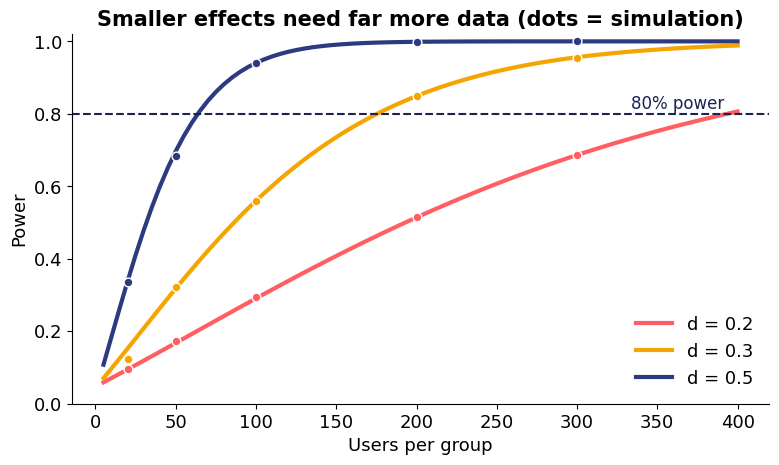

In [20]:
fig, ax = plt.subplots()
grid = np.arange(5, 401, 5)
for d, color in effect_sizes.items():
    ax.plot(grid, [power_analytic(d, n) for n in grid], color=color, lw=3, label=f"d = {d}")
    sim_points = [20, 50, 100, 200, 300]
    ax.scatter(sim_points, [power_sim(d, n) for n in sim_points], color=color, s=40, zorder=3, edgecolor="white")
ax.axhline(0.80, color=INK, ls="--", lw=1.5)
ax.text(392, 0.815, "80% power", ha="right", color=INK, fontsize=12)
ax.set_xlabel("Users per group")
ax.set_ylabel("Power")
ax.set_ylim(0, 1.02)
ax.set_title("Smaller effects need far more data (dots = simulation)")
ax.legend(frameon=False, loc="lower right")
save_fig(fig, "power_curve")
plt.show()

**Reading it:** the lines (formula) and dots (simulation) agree. Halving the effect size roughly **quadruples** the sample you need. The practical rule: **run the power calculation *before* the experiment**, so a "not significant" result means "no meaningful effect" rather than "we didn't collect enough data".

---

## 9 · Two traps that fool smart teams

### Trap 1 — Multiple testing
Test 20 metrics at α = 5% and, even when **nothing** is going on, the chance that at least one looks "significant" is

$$P(\text{at least one false alarm}) = 1 - (1 - \alpha)^{m} = 1 - 0.95^{20} \approx 64\%.$$

Let's confirm this with simulation: 5,000 experiments × 20 metrics, all pure noise. We also test two standard fixes:

* **Bonferroni:** use α ÷ m as the threshold. Simple and strict — controls the chance of *any* false positive.
* **Benjamini-Hochberg (BH):** controls the *false discovery rate* — the expected share of your "discoveries" that are false. More powerful when you test many things.

In [21]:
n_exp, m_tests, n = 5_000, 20, 50
a = rng.normal(size=(n_exp, m_tests, n))
b = rng.normal(size=(n_exp, m_tests, n))                  # every metric is pure noise
p = stats.ttest_ind(a, b, axis=2).pvalue                  # shape: (experiments, metrics)

any_raw  = np.mean((p < ALPHA).any(axis=1))                                   # no correction
any_bonf = np.mean((p < ALPHA / m_tests).any(axis=1))                         # Bonferroni
p_bh     = stats.false_discovery_control(p, axis=1, method="bh")              # BH-adjusted p-values
any_bh   = np.mean((p_bh < ALPHA).any(axis=1))

print(f"Experiments where NOTHING is real, {m_tests} metrics each:")
print(f"   theory  1 - 0.95^{m_tests}                   = {1 - (1 - ALPHA) ** m_tests:.3f}")
print(f"   no correction: at least one 'winner'   = {any_raw:.3f}")
print(f"   Bonferroni   : at least one 'winner'   = {any_bonf:.3f}")
print(f"   Benjamini-Hochberg: at least one 'winner' = {any_bh:.3f}")

curve = {m: float(np.mean((p[:, :m] < ALPHA).any(axis=1))) for m in (1, 2, 5, 10, 20)}
results["multiple_testing"] = {"m": m_tests, "theory": float(1 - (1 - ALPHA) ** m_tests),
                               "sim_raw": float(any_raw), "sim_bonferroni": float(any_bonf), "sim_bh": float(any_bh),
                               "sim_curve": curve}

Experiments where NOTHING is real, 20 metrics each:
   theory  1 - 0.95^20                   = 0.642
   no correction: at least one 'winner'   = 0.640
   Bonferroni   : at least one 'winner'   = 0.052
   Benjamini-Hochberg: at least one 'winner' = 0.053


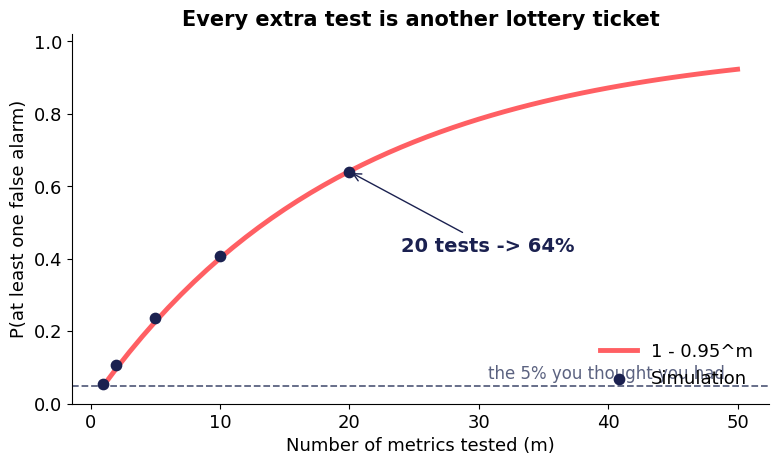

In [22]:
fig, ax = plt.subplots()
m_grid = np.arange(1, 51)
ax.plot(m_grid, 1 - (1 - ALPHA) ** m_grid, color=CORAL, lw=3.5, label="1 - 0.95^m")
ax.scatter(list(curve), list(curve.values()), color=INK, s=55, zorder=3, label="Simulation")
ax.axhline(ALPHA, color=MUTED, ls="--", lw=1.3)
ax.text(49, ALPHA + 0.02, "the 5% you thought you had", ha="right", color=MUTED, fontsize=12)
ax.annotate(f"20 tests -> {any_raw * 100:.0f}%", xy=(20, curve[20]), xytext=(24, 0.42),
            arrowprops=dict(arrowstyle="->", color=INK), color=INK, fontsize=14, fontweight="bold")
ax.set_xlabel("Number of metrics tested (m)")
ax.set_ylabel("P(at least one false alarm)")
ax.set_ylim(0, 1.02)
ax.set_title("Every extra test is another lottery ticket")
ax.legend(frameon=False, loc="lower right")
save_fig(fig, "multiple_testing")
plt.show()

**A realistic case:** 20 metrics in one A/B test, of which **3 are genuinely affected**. We flag winners three ways and see how many of the flags are real.

In [23]:
m, n = 20, 60
is_real = np.zeros(m, dtype=bool); is_real[:3] = True           # first 3 metrics have a real effect (d = 0.8)
p_vals = np.array([stats.ttest_ind(rng.normal(0.8 * r, 1, n), rng.normal(0, 1, n)).pvalue for r in is_real])

demo = pd.DataFrame({"metric": [f"metric_{i + 1:02d}" for i in range(m)],
                     "really_affected": is_real, "p_raw": p_vals,
                     "p_bh": stats.false_discovery_control(p_vals, method="bh")})
demo["raw_flag"]  = demo["p_raw"] < ALPHA
demo["bonf_flag"] = demo["p_raw"] < ALPHA / m
demo["bh_flag"]   = demo["p_bh"]  < ALPHA
display(demo.sort_values("p_raw").head(8).round(4).reset_index(drop=True))

print("\nWinners flagged (true positives / false positives):")
for label, col in [("No correction", "raw_flag"), ("Bonferroni", "bonf_flag"), ("Benjamini-Hochberg", "bh_flag")]:
    tp = int((demo[col] & demo["really_affected"]).sum())
    fp = int((demo[col] & ~demo["really_affected"]).sum())
    print(f"   {label:<20}: {tp} real, {fp} false")

,metric,really_affected,p_raw,p_bh,raw_flag,bonf_flag,bh_flag
0,metric_03,True,0.0000,0.0000,True,True,True
1,metric_02,True,0.0000,0.0000,True,True,True
2,metric_01,True,0.0001,0.0007,True,True,True
3,metric_10,False,0.0256,0.1154,True,False,False
4,metric_20,False,0.0288,0.1154,True,False,False
5,metric_13,False,0.0375,0.1250,True,False,False
6,metric_08,False,0.1419,0.3621,False,False,False
7,metric_18,False,0.1448,0.3621,False,False,False



Winners flagged (true positives / false positives):
   No correction       : 3 real, 3 false
   Bonferroni          : 3 real, 0 false
   Benjamini-Hochberg  : 3 real, 0 false


### Trap 2 — Statistically significant ≠ practically important
The p-value shrinks as the sample grows, *even if the effect stays tiny*. With 200,000 users per group, a **0.1-minute** difference on a metric whose standard deviation is 10 minutes will be "significant". Always look at the **effect size** and the **confidence interval** and ask: *would this change a decision?*

In [24]:
n_big = 200_000
big_a = rng.normal(50.0, 10.0, n_big)
big_b = rng.normal(50.1, 10.0, n_big)                 # true lift: 0.1 minutes on a 50-minute average (0.2%)

r = stats.ttest_ind(big_b, big_a, equal_var=False)
diff_big = big_b.mean() - big_a.mean()
d_big = diff_big / np.sqrt((big_a.var(ddof=1) + big_b.var(ddof=1)) / 2)
ci_big = r.confidence_interval(0.95)

print(f"Users per group   : {n_big:,}")
print(f"Observed lift     : {diff_big:.3f} minutes ({diff_big / big_a.mean() * 100:.2f}% of the average)")
print(f"95% CI            : [{ci_big.low:.3f}, {ci_big.high:.3f}] minutes")
print(f"Cohen's d         : {d_big:.3f}   (rule of thumb: 0.2 = 'small'; this is a fifth of that)")
print(verdict(r.pvalue))
print("\nStatistically significant? Yes. Worth shipping on its own? That is a business question, not a statistics question.")

results["practical"] = {"n_per_group": n_big, "diff": float(diff_big), "p": float(r.pvalue), "cohens_d": float(d_big)}

Users per group   : 200,000
Observed lift     : 0.102 minutes (0.20% of the average)
95% CI            : [0.040, 0.164] minutes
Cohen's d         : 0.010   (rule of thumb: 0.2 = 'small'; this is a fifth of that)
p = 0.001325 < alpha = 0.05  ->  REJECT H0 (statistically significant)

Statistically significant? Yes. Worth shipping on its own? That is a business question, not a statistics question.


**Reading it:** statistics tells you whether an effect is *detectable*; only you can decide whether it is *worth acting on*. Report **p-value + effect size + confidence interval** together — never the p-value alone.

---

## 10 · Cheat sheet — which test should I use?

The choice depends on three questions: **What is the outcome type? How many groups? Are the observations paired?** — plus whether the numeric data is reasonably normal.

In [25]:
cheat = pd.DataFrame([
    ("2 independent groups, numeric, ~normal", "Welch t-test",                  "stats.ttest_ind(a, b, equal_var=False)"),
    ("Same units measured twice, numeric",     "Paired t-test",                 "stats.ttest_rel(after, before)"),
    ("2 groups, yes/no outcome",               "Two-proportion z / chi-square", "stats.chi2_contingency(table, correction=False)"),
    ("2 independent groups, skewed / ordinal", "Mann-Whitney U",                "stats.mannwhitneyu(a, b)"),
    ("3+ independent groups, numeric",         "One-way ANOVA + Tukey HSD",     "stats.f_oneway(*g)  ->  stats.tukey_hsd(*g)"),
    ("3+ groups, skewed / ordinal",            "Kruskal-Wallis",                "stats.kruskal(*g)"),
    ("Paired, skewed / ordinal",               "Wilcoxon signed-rank",          "stats.wilcoxon(after, before)"),
    ("Small counts in a 2x2 table",            "Fisher's exact test",           "stats.fisher_exact(table)"),
], columns=["Situation", "Test", "SciPy call"])
cheat.style.hide(axis="index") if False else None      # keep plain output so it renders everywhere
display(cheat)

,Situation,Test,SciPy call
0,"2 independent groups, numeric, ~normal",Welch t-test,"stats.ttest_ind(a, b, equal_var=False)"
1,"Same units measured twice, numeric",Paired t-test,"stats.ttest_rel(after, before)"
2,"2 groups, yes/no outcome",Two-proportion z / chi-square,"stats.chi2_contingency(table, correction=False)"
3,"2 independent groups, skewed / ordinal",Mann-Whitney U,"stats.mannwhitneyu(a, b)"
4,"3+ independent groups, numeric",One-way ANOVA + Tukey HSD,stats.f_oneway(*g) -> stats.tukey_hsd(*g)
5,"3+ groups, skewed / ordinal",Kruskal-Wallis,stats.kruskal(*g)
6,"Paired, skewed / ordinal",Wilcoxon signed-rank,"stats.wilcoxon(after, before)"
7,Small counts in a 2x2 table,Fisher's exact test,stats.fisher_exact(table)


The same logic as a tiny reusable function — handy as a sanity check before you reach for a test.

In [26]:
def recommend_test(outcome, groups=2, paired=False, normal=True):
    """Suggest a classical test.

    outcome : 'numeric' or 'binary'
    groups  : number of groups being compared
    paired  : True if the same units are measured in every group
    normal  : True if the numeric data is roughly normal (or n is large)
    """
    if outcome == "binary":
        return "Two-proportion z / chi-square" if groups == 2 else "Chi-square test of independence"
    if groups == 2:
        if paired:
            return "Paired t-test" if normal else "Wilcoxon signed-rank"
        return "Welch t-test" if normal else "Mann-Whitney U"
    return "One-way ANOVA + Tukey HSD" if normal else "Kruskal-Wallis"

scenarios = [
    ("Weekly minutes, old vs new onboarding",   dict(outcome="numeric", groups=2, normal=True)),
    ("Latency of the same services, before/after", dict(outcome="numeric", groups=2, paired=True, normal=True)),
    ("Conversion, page A vs page B",            dict(outcome="binary",  groups=2)),
    ("Session duration, old vs new design",     dict(outcome="numeric", groups=2, normal=False)),
    ("Revenue per user across 3 channels",      dict(outcome="numeric", groups=3, normal=True)),
]
display(pd.DataFrame([(name, recommend_test(**kw)) for name, kw in scenarios], columns=["Scenario (this notebook)", "Recommended test"]))

,Scenario (this notebook),Recommended test
0,"Weekly minutes, old vs new onboarding",Welch t-test
1,"Latency of the same services, before/after",Paired t-test
2,"Conversion, page A vs page B",Two-proportion z / chi-square
3,"Session duration, old vs new design",Mann-Whitney U
4,Revenue per user across 3 channels,One-way ANOVA + Tukey HSD


## 11 · Save the headline numbers

We export every number collected in `results` to a JSON file. The carousel builder (`carousel/build_carousel.py`) reads this file, so **the numbers on the slides always match the notebook**.

In [27]:
results["meta"] = {"seed": SEED, "alpha": ALPHA,
                   "versions": {"numpy": np.__version__, "pandas": pd.__version__, "scipy": scipy.__version__}}

with open("results/results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved results/results.json with sections:", ", ".join(k for k in results if k != "meta"))
print("\nFiles created by this notebook:")
for folder in ("data", "images", "results"):
    for path in sorted(Path(folder).glob("*")):
        print(f"   {path}  ({path.stat().st_size / 1024:.0f} KB)")

Saved results/results.json with sections: pvalue_demo, welch, paired, proportions, mannwhitney, anova, type1, power, multiple_testing, practical

Files created by this notebook:
   data/ab_conversions.csv  (0 KB)
   data/channel_revenue.csv  (6 KB)
   data/latency_before_after.csv  (2 KB)
   data/onboarding_engagement.csv  (10 KB)
   data/session_duration.csv  (9 KB)
   images/anova.png  (115 KB)
   images/mannwhitney.png  (62 KB)
   images/multiple_testing.png  (104 KB)
   images/paired_ttest.png  (142 KB)
   images/power_curve.png  (112 KB)
   images/proportion_test.png  (58 KB)
   images/pvalue_null_distribution.png  (92 KB)
   images/welch_ttest.png  (59 KB)
   results/results.json  (3 KB)


---
## Key takeaways

1. **Hypothesis testing = "how surprising is this data if nothing were going on?"** The p-value is the tail area of that null distribution.
2. **Match the test to the data:** numeric vs. binary, two groups vs. many, paired vs. independent, normal vs. skewed.
3. **Report more than p:** effect size + confidence interval tell you *how much*, not just *whether*.
4. **Plan power up front.** Small effects need big samples; "not significant" from an under-powered test means very little.
5. **Beware the lottery:** testing many metrics inflates false alarms — correct for it (Bonferroni / Benjamini-Hochberg).
6. **Significant ≠ important.** Statistics detects; you decide.

**Try it yourself:** swap in your own metric — paste two columns into a DataFrame, pick a test with `recommend_test`, and report the p-value, effect size and CI.

*Next up — Day 5: Correlation vs. Causation, the #1 mistake in every deck.*